In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")
 

In [22]:
def load_data(cfg):
    df = pd.read_csv(cfg["file_path"], parse_dates=[cfg["date_col"]])
    df = df.sort_values(cfg["date_col"]).reset_index(drop=True)
 
    features = df[[cfg["revenue_col"], cfg["cogs_col"]]].values.astype(float)
 
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(features)   # shape: (T, 2)
 
    print(f"[INFO] Tổng số mẫu: {len(df)}")
    print(df[[cfg["date_col"], cfg["revenue_col"], cfg["cogs_col"]]].describe())
    return df, scaled, scaler
 

In [23]:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])      # (seq_len, 2)
        y.append(data[i + seq_len])           # (2,)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
 

In [24]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
 
 

In [25]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2,
                 output_size=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0,
            batch_first = True,
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, output_size),
        )
 
    def forward(self, x):
        out, _ = self.lstm(x)          # out: (batch, seq, hidden)
        out = self.fc(out[:, -1, :])   # lấy bước cuối
        return out


In [26]:
def train_model(model, loader, cfg):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=20, factor=0.5
    )
    criterion = nn.MSELoss()
 
    losses = []
    model.train()
 
    for epoch in range(1, cfg["epochs"] + 1):
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
 
        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        scheduler.step(avg_loss)
 
        if epoch % 20 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>4}/{cfg['epochs']}  Loss: {avg_loss:.6f}")
 
    return losses
 

In [27]:
def evaluate(model, X, y_true_scaled, scaler):
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X).to(DEVICE)
        preds_scaled = model(X_t).cpu().numpy()
 
    preds = scaler.inverse_transform(preds_scaled)
    y_true = scaler.inverse_transform(y_true_scaled)
 
    for i, name in enumerate(["Revenue", "COGS"]):
        mae  = mean_absolute_error(y_true[:, i], preds[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], preds[:, i]))
        mape = np.mean(np.abs((y_true[:, i] - preds[:, i]) /
                               (y_true[:, i] + 1e-8))) * 100
        print(f"  {name}: MAE={mae:,.2f}  RMSE={rmse:,.2f}  MAPE={mape:.2f}%")
 
    return preds, y_true


In [28]:
def predict_future(model, last_seq, scaler, steps):
    """
    last_seq: numpy array shape (seq_len, 2) — chuỗi cuối trong dataset (đã scale)
    """
    model.eval()
    seq = last_seq.copy()
    future_scaled = []
 
    with torch.no_grad():
        for _ in range(steps):
            x = torch.tensor(seq[np.newaxis], dtype=torch.float32).to(DEVICE)
            pred = model(x).cpu().numpy()[0]      # (2,)
            future_scaled.append(pred)
            seq = np.vstack([seq[1:], pred])      # slide window
 
    future_scaled = np.array(future_scaled)
    future = scaler.inverse_transform(future_scaled)
    return future


In [29]:
def plot_results(df, preds, y_true, future, losses, cfg):
    date_col = cfg["date_col"]
    seq_len  = cfg["seq_len"]
    steps    = cfg["predict_steps"]
 
    dates_actual = df[date_col].values[seq_len:]
 
    # Tạo ngày tương lai (giả sử monthly)
    last_date = pd.Timestamp(df[date_col].values[-1])
    future_dates = pd.date_range(last_date, periods=steps + 1, freq="D")[1:]
 
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle("LSTM – Revenue & COGS Forecast", fontsize=14, fontweight="bold")
 
    for i, (name, color) in enumerate([("Revenue", "#2196F3"), ("COGS", "#E91E63")]):
        ax = axes[i]
        ax.plot(dates_actual, y_true[:, i],
                label="Actual", color=color, linewidth=1.8)
        ax.plot(dates_actual, preds[:, i],
                label="Fitted", color=color, linewidth=1.2,
                linestyle="--", alpha=0.8)
        ax.plot(future_dates, future[:, i],
                label=f"Forecast (+{steps})", color="orange",
                linewidth=2, marker="o", markersize=5)
        ax.set_title(name)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x:,.0f}")
        )
 
    # Loss curve
    ax = axes[2]
    ax.plot(losses, color="#4CAF50", linewidth=1.5)
    ax.set_title("Training Loss (MSE)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
 
    plt.tight_layout()
    plt.savefig("lstm_forecast.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[INFO] Đã lưu biểu đồ: lstm_forecast.png")


In [30]:
real_test = pd.read_csv("../../sample_submission.csv")
real_test.drop(['Revenue', 'COGS'], axis=1, inplace=True)


In [31]:
real_test.head()


,Date
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05


[INFO] Tổng số mẫu: 3833
                      Date       Revenue          COGS
count                 3833  3.833000e+03  3.833000e+03
mean   2017-10-02 00:00:00  4.286584e+06  3.695134e+06
min    2012-07-04 00:00:00  2.798139e+05  2.365763e+05
25%    2015-02-17 00:00:00  2.471089e+06  2.150580e+06
50%    2017-10-02 00:00:00  3.647304e+06  3.161113e+06
75%    2020-05-17 00:00:00  5.350877e+06  4.637294e+06
max    2022-12-31 00:00:00  2.090527e+07  1.653586e+07
std                    NaN  2.624840e+06  2.219789e+06
[INFO] X.shape=(3821, 12, 2), y.shape=(3821, 2)
[INFO] Tổng tham số: 52,834

[TRAIN] Bắt đầu training...
  Epoch    1/200  Loss: 0.015095
  Epoch   20/200  Loss: 0.003035
  Epoch   40/200  Loss: 0.002589
  Epoch   60/200  Loss: 0.002371
  Epoch   80/200  Loss: 0.002195
  Epoch  100/200  Loss: 0.001898
  Epoch  120/200  Loss: 0.001646
  Epoch  140/200  Loss: 0.001336
  Epoch  160/200  Loss: 0.001147
  Epoch  180/200  Loss: 0.000907
  Epoch  200/200  Loss: 0.000687
[TRAIN] Hoàn

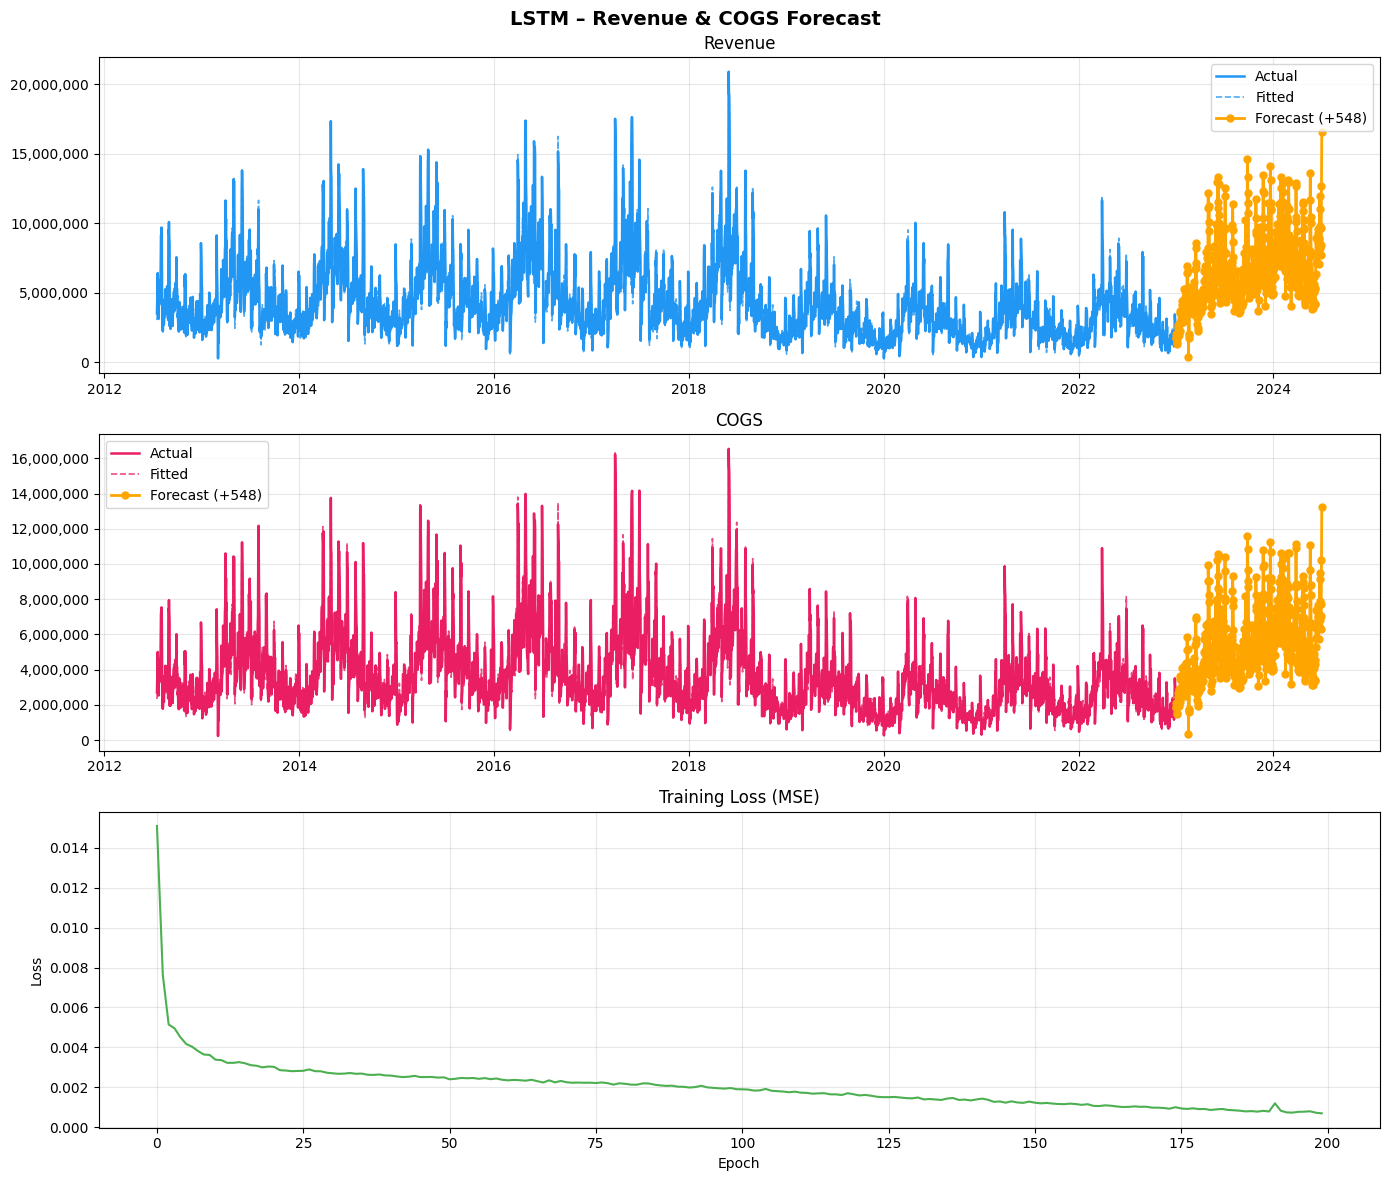

[INFO] Đã lưu biểu đồ: lstm_forecast.png
[INFO] Đã lưu file dự đoán: lstm_submission.csv


In [32]:
cfg = CONFIG

# --- Load ---
df, scaled, scaler = load_data(cfg)

# --- Sequences ---
X, y = create_sequences(scaled, cfg["seq_len"])
print(f"[INFO] X.shape={X.shape}, y.shape={y.shape}")

dataset = TimeSeriesDataset(X, y)
loader  = DataLoader(dataset, batch_size=cfg["batch_size"], shuffle=True)

# --- Model ---
model = LSTMModel(
    input_size  = 2,
    hidden_size = cfg["hidden_size"],
    num_layers  = cfg["num_layers"],
    output_size = 2,
    dropout     = cfg["dropout"],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"[INFO] Tổng tham số: {total_params:,}")

# --- Train ---
print("\n[TRAIN] Bắt đầu training...")
losses = train_model(model, loader, cfg)
print("[TRAIN] Hoàn thành!\n")

# --- Evaluate ---
print("[EVAL] Metrics trên toàn bộ dữ liệu:")
preds, y_true = evaluate(model, X, y, scaler)

# --- Forecast ---
last_seq = scaled[-cfg["seq_len"]:]
future   = predict_future(model, last_seq, scaler, cfg["predict_steps"])

print(f"\n[FORECAST] {cfg['predict_steps']} bước tiếp theo:")
print(f"{'Step':>5} {'Revenue':>15} {'COGS':>15}")
for i, (rev, cogs) in enumerate(future, 1):
    print(f"{i:>5} {rev:>15,.2f} {cogs:>15,.2f}")

# --- Save model ---
torch.save(model.state_dict(), "lstm_model.pt")
print("\n[INFO] Đã lưu model: lstm_model.pt")

# --- Plot ---
plot_results(df, preds, y_true, future, losses, cfg)

print("[INFO] Đã lưu file dự đoán: lstm_submission.csv")


In [33]:
real_test['Revenue'] = future[:, 0]
real_test['COGS']    = future[:, 1]
real_test.to_csv("lstm_submission.csv", index=False)
